# London AV Geofence — Closed Roads Pipeline

**Purpose:** Build a clean, filtered set of road-network blocks for London from raw OSM data.
Blocks are scored by park and water coverage, noisy blocks are removed, and the largest
connected component is extracted. The result is the spatial unit used by the geofence
optimiser and the trip-block assignment pipeline.

**Input:** `data/raw/greater-london-260411.osm.pbf`

**Output:** `data/processed/filtered_main_blocks.geojson`

**What is important for you in this notebook?**

It is a "technical" notebook in which I step by step define a main connected component (so that we do not have any islands), and divide it into the smallest possible closed-by-roads blocks to build geofence for AV later.

Here are some pretty graphs for blocks defined. They do not bring any additional insights, but I needed them to understand better the data I am working with.

**How road blocks are defined**

Road centre-lines from OSM are treated as a graph, every intersection is a node,
every road segment between two intersections is an edge. The algorithm (`shapely.polygonize`)
finds all **closed blcoks** of this graph: starting from any edge, it always takes the
most right turn at each junction, tracing the boundary of the smallest
enclosed area. Each such closed ring becomes one block polygon.

This produces one polygon per enclosed area in the road network: residential blocks,
roundabout islands, park interiors, etc. Blocks bounded by motorways or arterials tend
to be large; blocks inside dense street grids are small.

I think this is a perfect way to construct a geofece for AV, so that tehre are no abruptly cut roads, and car could freely "rotate" within a block.

**Something to take care in the future**

- Take into account roads directions
- Even though, I tried to substarct from water zones with buffer of 20m any roads present on them, so I could keep bridges, not all of them are represented in the final connected component. Thus, in the future, when the gefence is calcualted, it almost never spreads in the area below the Thames.


**All Contents**

0. Imports & config
1. Load road network & build blocks — parse OSM PBF, polygonize road centre-lines into block polygons
2. Park coverage — compute fraction of each block's area covered by OSM park/leisure polygons
3. Water coverage — compute fraction covered by OSM water polygons (bridges and slivers removed)
4. Manual tweaks — cap park fraction artefacts at 1.0; reset spurious water blocks (> 0.95) to 0 (This steps are definded solely on manual inspection)
5. Filter blocks & final connected component — drop high-park / high-water blocks, keep largest component, save

## 0. Imports & Config

In [2]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import geopandas as gpd
import matplotlib.pyplot as plt

import src.config as cfg
from src.blocks import (
    load_osm_data,
    make_road_blocks,
    find_main_component,
    load_osm_polygons,
    compute_coverage_fraction,
    filter_blocks,
)
from src.viz import (
    plot_fraction_choropleth,
    plot_before_after_filter,
    plot_final_component,
)

print('Imports OK')

Imports OK


---
## 1. Load Road Network & Build Blocks

In [3]:
osm, roads = load_osm_data(cfg.PBF_FILE, cfg.BBOX, cfg.ROAD_TYPES, cfg.TARGET_CRS)
blocks_gdf = make_road_blocks(roads)
blocks = blocks_gdf.copy()

Roads loaded:  138,377
Road types:    ['living_street', 'motorway', 'motorway_link', 'primary', 'primary_link', 'residential', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link', 'trunk', 'trunk_link']
CRS:           EPSG:27700
Blocks after polygonisation: 34,329


---
## 2. Park Coverage

In [4]:
parks = load_osm_polygons(
    osm, cfg.TARGET_CRS,
    landuse_tags=cfg.PARK_LANDUSE,
    leisure_tags=cfg.PARK_LEISURE,
)
blocks = compute_coverage_fraction(blocks, parks, "park")

OSM polygons loaded: 31,793


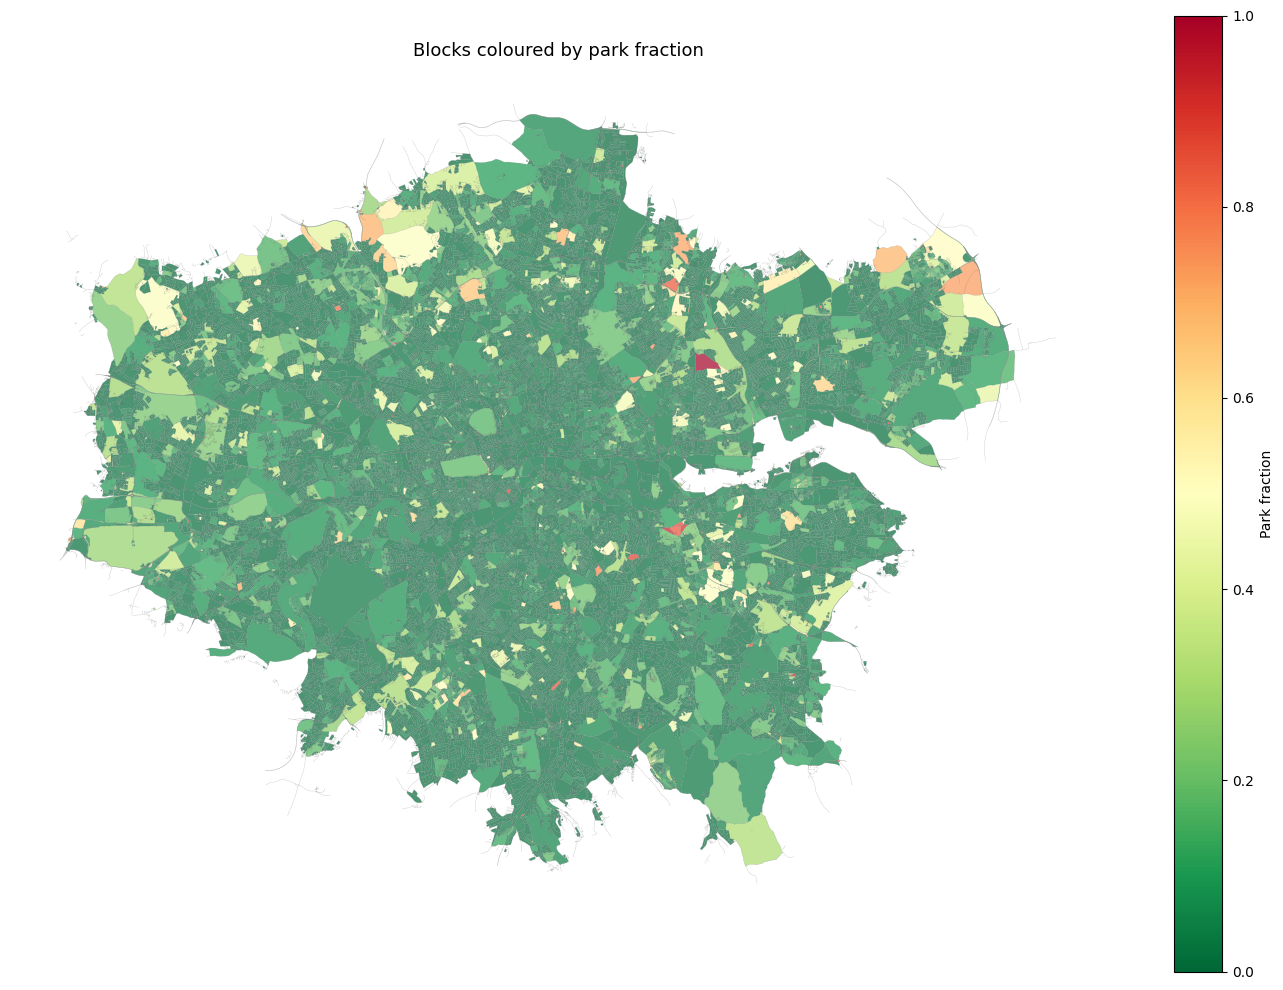

In [5]:
plot_fraction_choropleth(
    blocks, roads,
    column='park_fraction', label='Park fraction',
    title='Blocks coloured by park fraction',
)

---
## 3. Water Coverage

In [6]:
water = load_osm_polygons(
    osm, cfg.TARGET_CRS,
    landuse_tags=cfg.WATER_LANDUSE,
    natural_tags=cfg.WATER_NATURAL,
    roads=roads, road_buffer_m=cfg.ROAD_BUFFER_M,
)
blocks = compute_coverage_fraction(blocks, water, "water")

OSM polygons loaded: 3,690
After road masking (20 m buffer): 3,679


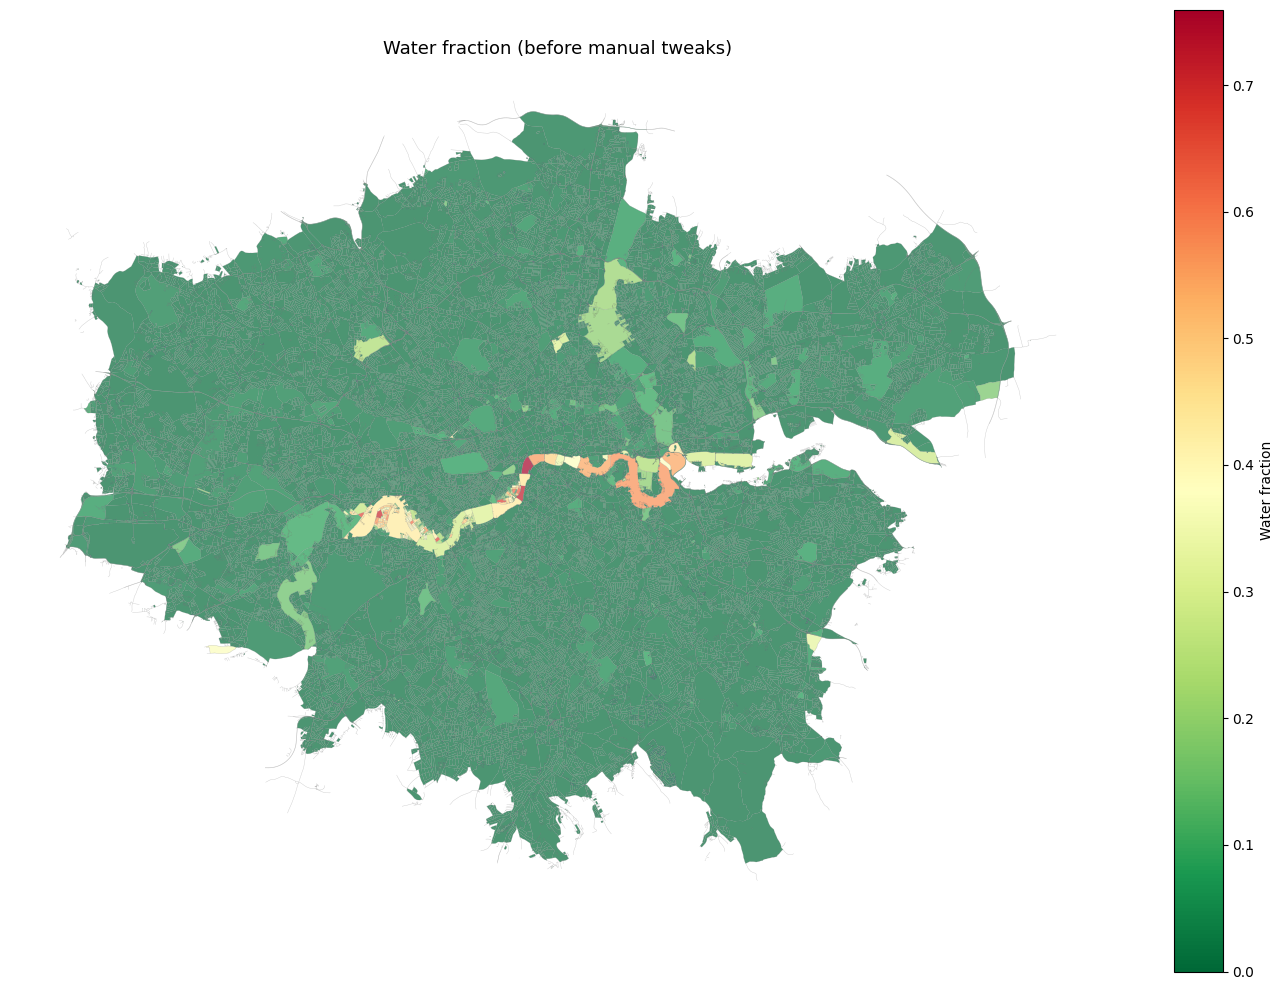

In [7]:
# Inspect before tweaks — spurious blocks (bridges / OSM errors) appear at water_fraction > 0.95
plot_fraction_choropleth(
    blocks, roads,
    column='water_fraction', label='Water fraction',
    title='Water fraction (before manual tweaks)',
)

---
## 4. Manual Tweaks
- Park fraction capped at 1.0 (geometry artefact guard)
- `water_fraction > 0.95` reset to 0 — manual inspection shows these are not water areas

In [ ]:
# Cap park fraction at 1.0 (geometry artefact guard)
mask_park = blocks['park_fraction'] > 1.0
blocks.loc[mask_park, 'park_fraction'] = 1.0
blocks.loc[mask_park, 'park_area_m2']  = blocks.loc[mask_park, 'block_area_m2']

# Zero out spurious water — blocks with water_fraction > 0.95
# or OSM tagging errors confirmed by manual inspection
mask_water = blocks['water_fraction'] > cfg.WATER_SPURIOUS_THRESHOLD
blocks.loc[mask_water, 'water_fraction'] = 0.0
blocks.loc[mask_water, 'water_area_m2']  = 0.0


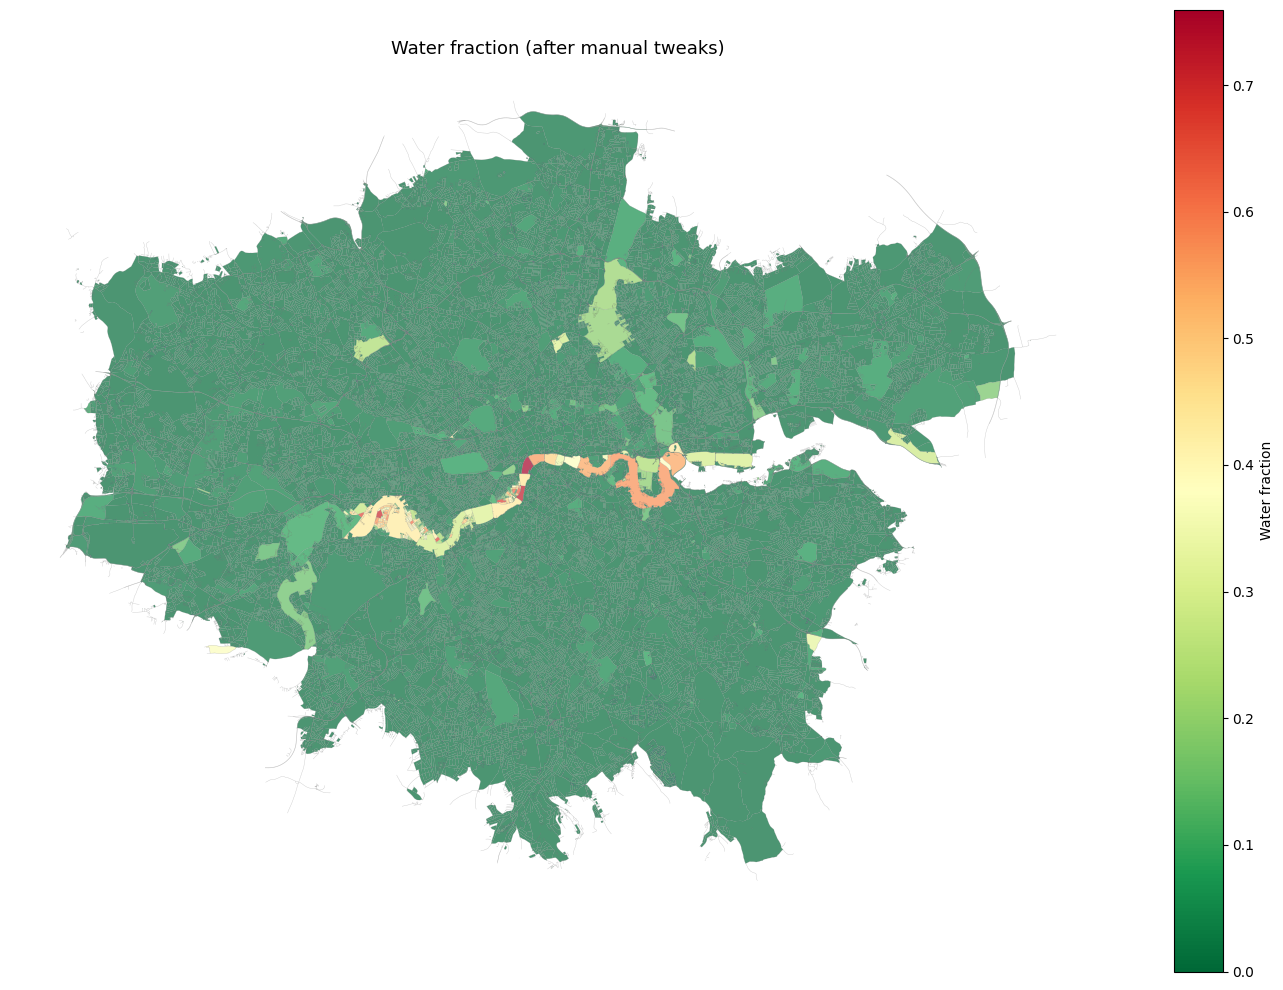

In [9]:
plot_fraction_choropleth(
    blocks, roads,
    column='water_fraction', label='Water fraction',
    title='Water fraction (after manual tweaks)',
)

---
## 5. Filter Blocks & Final Connected Component

In [10]:
filtered = filter_blocks(
    blocks,
    park_threshold=cfg.BLOCK_PARK_THRESHOLD,
    water_threshold=cfg.BLOCK_WATER_THRESHOLD,
)

Blocks removed (park≥0.1 or water≥0.1): 3,000  →  31,329 remain


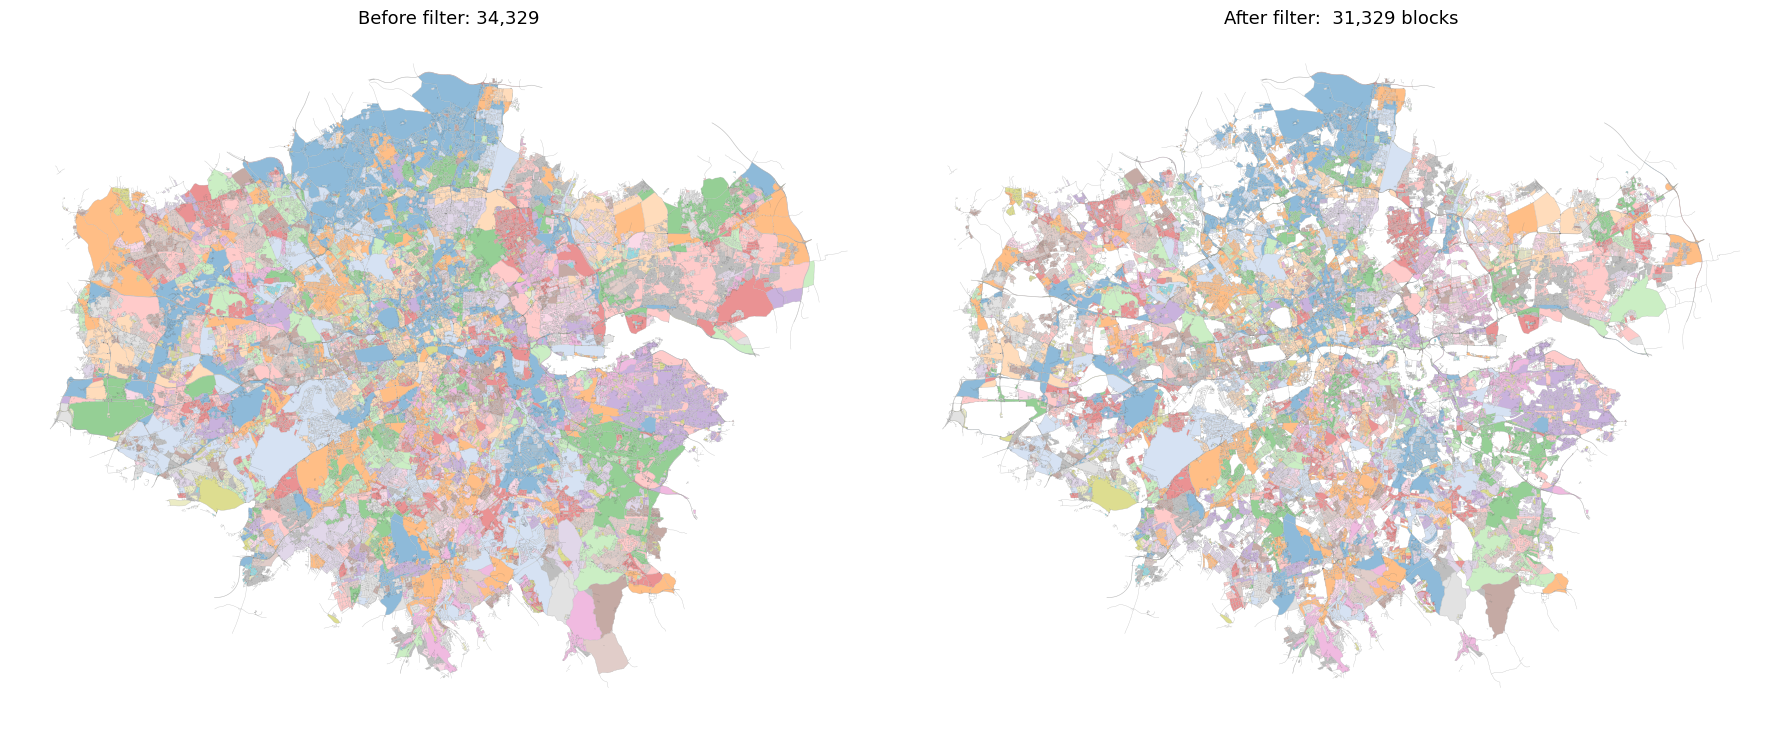

In [11]:
plot_before_after_filter(blocks, filtered, roads)

In [12]:
filtered_main, filtered_hull = find_main_component(filtered)

Connected components found: 790
Blocks in main component:   29,480


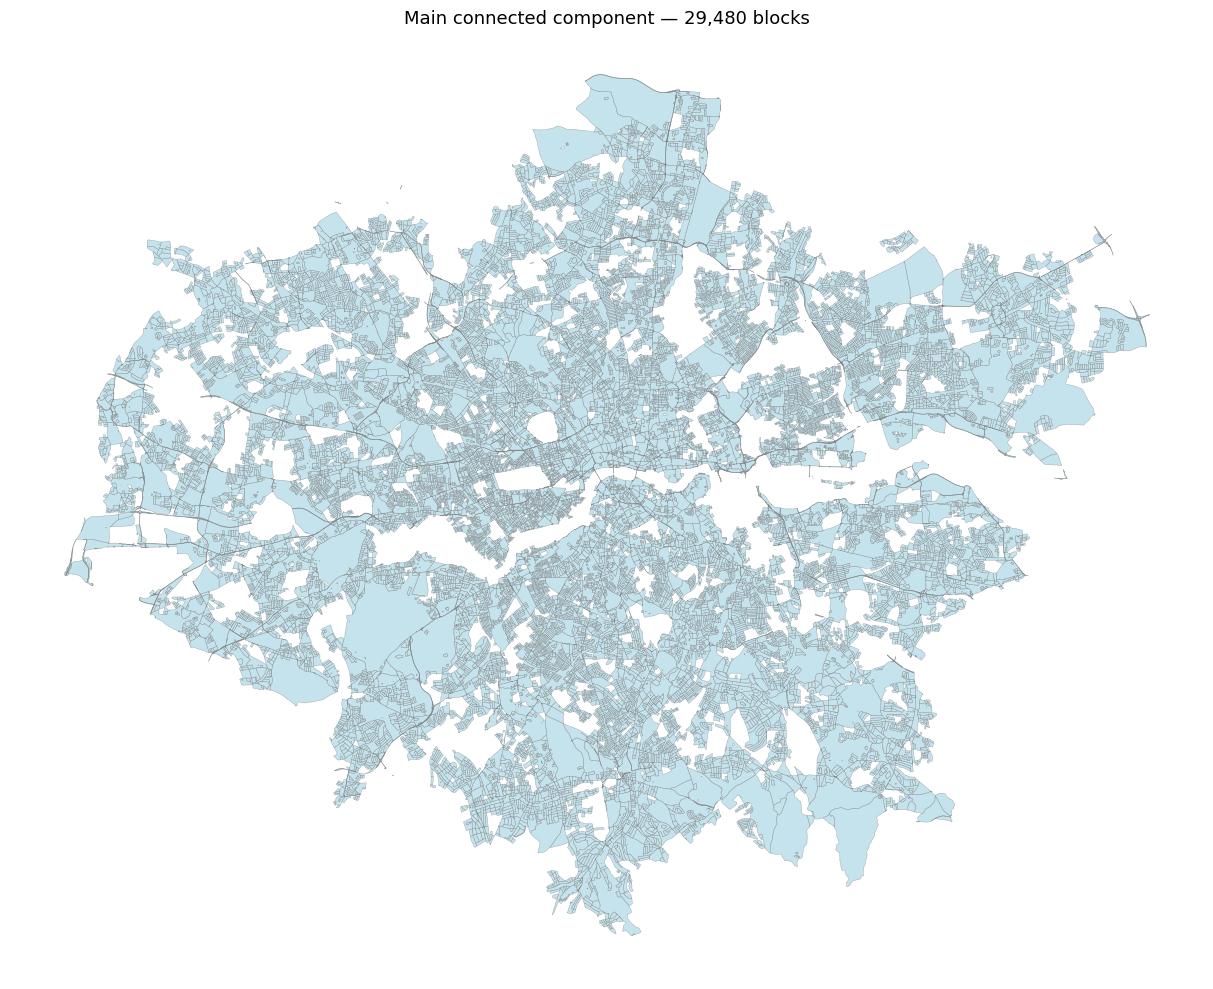

In [13]:
plot_final_component(filtered_main)

In [15]:
filtered_main.to_file(cfg.FILTERED_BLOCKS_FILE, driver='GeoJSON')
print(f'Saved filtered_main_blocks.geojson  ({len(filtered_main):,} blocks)')

Saved filtered_main_blocks.geojson  (29,480 blocks)
